# Debug Gripper Transform & Model Inference

This notebook demonstrates:
1. Loading a trained Pi-0 model checkpoint
2. Loading a LeRobot dataset
3. Processing a frame through the model (same as training)
4. Inspecting normalized state/actions
5. Unnormalizing actions
6. Applying reverse gripper transform

In [11]:
import sys
sys.path.insert(0, '../../src')

import numpy as np
import jax
import jax.numpy as jnp
from pathlib import Path
import json

# OpenPI imports
import openpi.shared.normalize as normalize
import openpi.transforms as _transforms

# LeRobot imports
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata

print(f"JAX devices: {jax.devices()}")
print(f"JAX default backend: {jax.default_backend()}")

JAX devices: [CudaDevice(id=0)]
JAX default backend: gpu


## 1. Define Gripper Transform Functions

In [8]:
def apply_gripper_transform(values: np.ndarray, gripper_indices: list[int], gripper_range: tuple[float, float]) -> np.ndarray:
    """Transform gripper joints from physical range to [1, 0] range."""
    values = values.copy()
    min_val, max_val = gripper_range
    for idx in gripper_indices:
        values[..., idx] = 1.0 - (values[..., idx] - min_val) / (max_val - min_val)
    return values

def reverse_gripper_transform(actions: np.ndarray, gripper_indices: list[int], gripper_range: tuple[float, float]) -> np.ndarray:
    """Transform gripper joints from [1, 0] range back to physical range."""
    if gripper_indices is None or gripper_range is None:
        return actions
    actions = actions.copy()
    min_val, max_val = gripper_range
    for idx in gripper_indices:
        actions[..., idx] = min_val + (1.0 - actions[..., idx]) * (max_val - min_val)
    return actions

GRIPPER_INDICES = [6, 13]
GRIPPER_RANGE = (0.0, 0.045)
print(f"Gripper indices: {GRIPPER_INDICES}")
print(f"Gripper physical range: {GRIPPER_RANGE}")

Gripper indices: [6, 13]
Gripper physical range: (0.0, 0.045)


## 2. Load Norm Stats

In [18]:
from pathlib import Path

norm_stats_path = Path("/home/sherry/ChefResearch/sandi/third_party/openpi/assets/pi0_lettuce_sandwich_3p3")
print(f"Loading norm_stats from: {norm_stats_path}")
norm_stats_dict_full = normalize.load(norm_stats_path)

print("\nOriginal norm stats shapes:")
print(f"  State mean: {norm_stats_dict_full['state'].mean.shape}")
print(f"  Actions mean: {norm_stats_dict_full['actions'].mean.shape}")

# The norm_stats are padded to 32 dims, but we only need the first 14 for bimanual WidowX
NUM_JOINTS = 14
print(f"\nSlicing to first {NUM_JOINTS} joints...")

# Create sliced norm stats
norm_stats_dict = {
    'state': normalize.NormStats(
        mean=norm_stats_dict_full['state'].mean[:NUM_JOINTS],
        std=norm_stats_dict_full['state'].std[:NUM_JOINTS],
        q01=norm_stats_dict_full['state'].q01[:NUM_JOINTS],
        q99=norm_stats_dict_full['state'].q99[:NUM_JOINTS]
    ),
    'actions': normalize.NormStats(
        mean=norm_stats_dict_full['actions'].mean[:NUM_JOINTS],
        std=norm_stats_dict_full['actions'].std[:NUM_JOINTS],
        q01=norm_stats_dict_full['actions'].q01[:NUM_JOINTS],
        q99=norm_stats_dict_full['actions'].q99[:NUM_JOINTS]
    )
}

print(f"\nSliced norm stats shapes:")
print(f"  State mean: {norm_stats_dict['state'].mean.shape}")
print(f"  Actions mean: {norm_stats_dict['actions'].mean.shape}")

print("\nGripper Joint Statistics:")
for idx in GRIPPER_INDICES:
    print(f"Joint {idx}:")
    print(f"  Action q01: {norm_stats_dict['actions'].q01[idx]:.6f}, q99: {norm_stats_dict['actions'].q99[idx]:.6f}")

Loading norm_stats from: /home/sherry/ChefResearch/sandi/third_party/openpi/assets/pi0_lettuce_sandwich_3p3

Original norm stats shapes:
  State mean: (32,)
  Actions mean: (32,)

Slicing to first 14 joints...

Sliced norm stats shapes:
  State mean: (14,)
  Actions mean: (14,)

Gripper Joint Statistics:
Joint 6:
  Action q01: 0.305848, q99: 1.004216
Joint 13:
  Action q01: 0.632888, q99: 1.003292


## 3. Load Dataset & Get Sample

In [19]:
repo_id = "sandi/lettuce-sandwich"
dataset_root = Path("/home/sherry/ChefResearch/sandi/datasets/sandi/lettuce-sandwich")
dataset_meta = LeRobotDatasetMetadata(repo_id, root=dataset_root)
action_horizon = 50

dataset = LeRobotDataset(
    repo_id, root=dataset_root,
    delta_timestamps={"action": [t / dataset_meta.fps for t in range(action_horizon)]}
)

sample_idx = 1000
raw_sample = dataset[sample_idx]
raw_state = np.array(raw_sample['observation.state'])
raw_actions = np.array(raw_sample['action'])

print(f"Sample {sample_idx}: Episode {raw_sample['episode_index'].item()}")
print(f"Raw state: {raw_state}")
print(f"Raw actions shape: {raw_actions.shape}")
print("\nGripper values (raw):")
for idx in GRIPPER_INDICES:
    print(f"  Joint {idx}: state={raw_state[idx]:.6f}, action[0]={raw_actions[0, idx]:.6f}")

Resolving data files:   0%|          | 0/169 [00:00<?, ?it/s]

Sample 1000: Episode 0
Raw state: [ 2.7256429e-01  1.2941558e+00  6.2619209e-01  4.1752499e-01
  5.7793546e-02 -1.0278859e+00  1.8272549e-05 -7.8011751e-02
  1.4173723e+00  1.3250554e+00 -3.4542611e-01  6.0082398e-02
  1.7643245e-01  1.3910660e-02]
Raw actions shape: (50, 14)

Gripper values (raw):
  Joint 6: state=0.000018, action[0]=-0.000095
  Joint 13: state=0.013911, action[0]=0.013914


## 4. Apply Normalization (Training Pipeline)

In [17]:
raw_actions.shape

(50, 14)

In [20]:
normalizer = _transforms.Normalize(norm_stats_dict, use_quantiles=True)
normalized_sample = normalizer({'state': raw_state, 'actions': raw_actions})
normalized_state = normalized_sample['state']
normalized_actions = normalized_sample['actions']

print("Normalized state:", normalized_state)
print(f"Normalized actions[0]: {normalized_actions[0]}")
print("\nGripper values (normalized to [-1, 1]):")
for idx in GRIPPER_INDICES:
    print(f"  Joint {idx}: {raw_state[idx]:.6f} -> {normalized_state[idx]:.6f}")

Normalized state: [ 0.0674261  -0.08223484 -0.22448421  0.33871241  0.2290103  -0.15738313
 -1.87984389  0.0416577  -0.052704    0.38159687 -0.0534414  -0.32081686
 -0.10174472 -4.3781798 ]
Normalized actions[0]: [ 0.58313134  2.08155966  1.69368766  0.56787185  0.0956139  -1.44839578
 -1.87616549 -0.30226092  2.79894177  2.98161293 -0.42901356  0.06410865
  0.25910439 -4.34215344]

Gripper values (normalized to [-1, 1]):
  Joint 6: 0.000018 -> -1.879844
  Joint 13: 0.013911 -> -4.378180


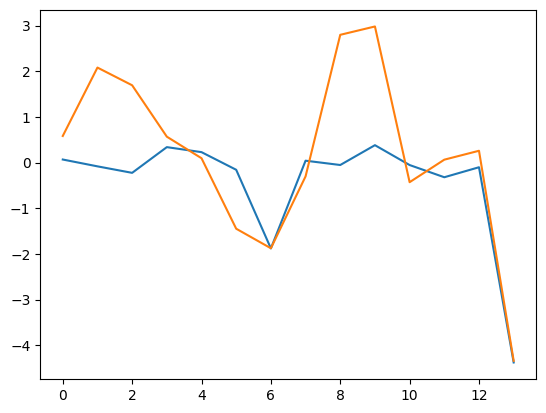

In [22]:
from matplotlib import pyplot as plt
plt.plot(normalized_state, label="state")
plt.plot(normalized_actions[0], label="actions")


Soo, basically what happened was:
- In compute_norm_stats.py, I transformed the gripper joints from (0,0.045) to (1, 0)
- When model loads the data, it still loads the raw gripper joint data. Then it used the incorrect norm_stats to convert gripper joints to ... -2, -4, like the above
- what should have happened:
  - A preprocessing step should convert gripper joints from (-0.004, 0.044) to (1, 0). This can just happen in the dataset itself.
  - norm_stats.py will work correctly. So will the training script.
  - during inference (main.py), convert model output (which is in (1, 0)) to (-0.004, 0.044)

## 5. Simulate Model Output

In [ ]:
model_output_actions = normalized_actions.copy()
print("Model output (simulated, normalized):")
print(f"Shape: {model_output_actions.shape}")
print(f"First action: {model_output_actions[0]}")
print("\nGripper values:")
for idx in GRIPPER_INDICES:
    print(f"  Joint {idx}: {model_output_actions[0, idx]:.6f}")

## 6. Unnormalize Model Output

In [ ]:
unnormalizer = _transforms.Unnormalize(norm_stats_dict, use_quantiles=True)
unnormalized_sample = unnormalizer({'actions': model_output_actions})
unnormalized_actions = unnormalized_sample['actions']

print("Unnormalized actions:")
print(f"First action: {unnormalized_actions[0]}")
print("\nGripper values (unnormalized):")
for idx in GRIPPER_INDICES:
    print(f"  Joint {idx}:")
    print(f"    Normalized: {model_output_actions[0, idx]:.6f}")
    print(f"    Unnormalized: {unnormalized_actions[0, idx]:.6f}")
    print(f"    Original: {raw_actions[0, idx]:.6f}")
    print(f"    Error: {abs(unnormalized_actions[0, idx] - raw_actions[0, idx]):.8f}")

## 7. Apply Reverse Gripper Transform

In [ ]:
robot_actions = reverse_gripper_transform(unnormalized_actions, GRIPPER_INDICES, GRIPPER_RANGE)

print("Robot actions (after reverse gripper transform):")
print(f"First action: {robot_actions[0]}")
print("\nComplete transform chain for grippers:")
for idx in GRIPPER_INDICES:
    print(f"\nJoint {idx}:")
    print(f"  1. Raw: {raw_actions[0, idx]:.6f}")
    print(f"  2. Normalized: {normalized_actions[0, idx]:.6f}")
    print(f"  3. Model output: {model_output_actions[0, idx]:.6f}")
    print(f"  4. Unnormalized: {unnormalized_actions[0, idx]:.6f}")
    print(f"  5. After reverse transform: {robot_actions[0, idx]:.6f}")
    print(f"  Range: [{GRIPPER_RANGE[0]}, {GRIPPER_RANGE[1]}]")